# 정밀 Mutation Feature 실험

기존 `team_baseline_binary`를 기준으로, mutation type의 전체 개수 대신 **유전자·위치·반복성·유전자 내부 다중 변이**를 좁고 정밀하게 표현합니다.

## 실험 순서

1. `Baseline + Gene x Codon`
2. `Baseline + Gene-specific Functional State`
3. `Baseline + Recurrent Exact Hotspot` (`count >= 5`, `10`, `20`)
4. `Baseline + Hotspot / Non-hotspot State`
5. `Baseline + Gene-level Multi-hit`
6. `Baseline + Functional State + Gene x Codon`
7. `Baseline + Gene x Codon + Hotspot State`
8. `Baseline + All Precision Groups`

모든 결과는 기존 benchmark와 동일하게 Logistic Regression과 LightGBM의 OOF Macro F1, Accuracy, fold별 변동성을 비교합니다.

> 누수 방지: 암종별 top gene, codon hotspot, exact recurrent mutation 목록은 각 CV fold의 `X_train`, `y_train`으로만 생성합니다. 최종 test 학습 때는 전체 train으로 다시 fit한 뒤 test에 transform해야 합니다.

In [1]:
from __future__ import annotations

from collections import Counter, defaultdict
from dataclasses import dataclass
import os
from pathlib import Path
import re
import sys
import tempfile
from typing import Any

os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'matplotlib-member-b-precision'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import sparse
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from tqdm.auto import tqdm

pd.set_option('display.max_columns', 200)


def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / 'requirements.txt').exists() and (path / 'experiments').exists():
            return path
    raise FileNotFoundError('저장소 루트를 찾지 못했습니다.')


ROOT = find_project_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from common.preprocessing_benchmark import run_preprocessing_benchmark
from common.starter_preprocess import make_baseline_preprocessor

print('project root:', ROOT)

project root: /Users/admin/Documents/FinalProject/OZ_fianl_hackaton


/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
@dataclass(frozen=True)
class NotebookConfig:
    id_col: str = 'ID'
    target_col: str = 'SUBCLASS'
    wt_value: str = 'WT'
    top_genes_per_class: int = 5
    codon_min_count: int = 5


CONFIG = NotebookConfig()
EXPERIMENT_MODE = 'benchmark'  # 'benchmark' | 'fast'
FAST_SAMPLE_PER_CLASS = 30
RUN_MODELS = ['logistic', 'lightgbm']
USE_CONFIRMATION = False

train_df = pd.read_csv(ROOT / 'data' / 'raw' / 'train.csv')


def prepare_experiment_dataset(dataframe: pd.DataFrame) -> pd.DataFrame:
    if EXPERIMENT_MODE == 'benchmark':
        return dataframe.copy()
    parts = []
    for _, class_frame in dataframe.groupby(CONFIG.target_col, sort=True):
        n = min(len(class_frame), max(FAST_SAMPLE_PER_CLASS, 5))
        parts.append(class_frame.sample(n=n, random_state=42))
    return pd.concat(parts, ignore_index=True)


experiment_train_df = prepare_experiment_dataset(train_df)
GENE_COLUMNS = [c for c in train_df.columns if c not in {CONFIG.id_col, CONFIG.target_col}]
print('train shape:', train_df.shape)
print('experiment rows:', len(experiment_train_df))
print('gene columns:', len(GENE_COLUMNS))

train shape: (6201, 4386)
experiment rows: 6201
gene columns: 4384


## Feature 정의

- **Functional State**: 선택된 gene에서 `missense_like`, `truncating`, `other` 발생 여부
- **Gene x Codon**: `PIK3CA_H1047`처럼 amino-acid 위치까지만 묶고, fold train에서 반복된 위치만 사용
- **Recurrent Exact Hotspot**: `PIK3CA_H1047R`처럼 정확한 token을 fold train count 기준으로 선택
- **Hotspot State**: 선택된 gene을 `known_recurrent`와 `other_mutation`으로 분리
- **Multi-hit**: 한 gene 셀에 두 개 이상의 mutation token이 기록된 경우

기본 mutation binary 4,384개는 계속 유지하고, 새 그룹만 뒤에 추가합니다. WT 자체는 기존 binary에서 이미 표현되므로 중복 WT 피처는 만들지 않습니다.

In [3]:
TOKEN_RE = re.compile(r'^(?P<ref>[A-Z])(?P<position>\d+)(?P<alt>[A-Z*])$')
CODON_RE = re.compile(r'^(?P<ref>[A-Z])(?P<position>\d+)')


def clean_tokens(value: Any, wt_value: str = 'WT') -> list[str]:
    if pd.isna(value):
        return []
    text = str(value).strip()
    if not text or text == wt_value:
        return []
    return [token for token in text.split() if token and token != wt_value]


def mutation_kind(token: str) -> str:
    token = str(token)
    if 'fs' in token.lower() or '*' in token or 'ter' in token.lower():
        return 'truncating'
    if TOKEN_RE.match(token):
        return 'missense_like'
    return 'other'


def codon_key(token: str) -> str | None:
    match = CODON_RE.match(str(token))
    if not match:
        return None
    return f"{match.group('ref')}{match.group('position')}"


def token_counter(dataframe: pd.DataFrame, genes: list[str], wt_value: str) -> Counter:
    counts = Counter()
    for gene in genes:
        for value in dataframe[gene].array:
            counts.update((f'{gene}::{token}' for token in clean_tokens(value, wt_value)))
    return counts


def codon_counter(dataframe: pd.DataFrame, genes: list[str], wt_value: str) -> Counter:
    counts = Counter()
    for gene in genes:
        for value in dataframe[gene].array:
            for token in clean_tokens(value, wt_value):
                codon = codon_key(token)
                if codon is not None:
                    counts[f'{gene}::{codon}'] += 1
    return counts

In [4]:
class PrecisionMutationEncoder(BaseEstimator, TransformerMixin):
    """Fold-safe baseline binary plus one or more precise mutation groups."""

    def __init__(
        self,
        *,
        strategy: str = 'functional_state',
        wt_value: str = 'WT',
        top_genes_per_class: int = 5,
        codon_min_count: int = 5,
        exact_min_count: int = 5,
    ) -> None:
        self.strategy = strategy
        self.wt_value = wt_value
        self.top_genes_per_class = top_genes_per_class
        self.codon_min_count = codon_min_count
        self.exact_min_count = exact_min_count

    def fit(self, X: pd.DataFrame, y: Any = None):
        if not isinstance(X, pd.DataFrame):
            raise TypeError('PrecisionMutationEncoder는 pandas DataFrame이 필요합니다.')
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.gene_columns_ = list(X.columns)
        normalized = X.reindex(columns=self.gene_columns_).fillna(self.wt_value).astype(str)
        mutated = normalized.ne(self.wt_value)

        if y is None:
            y_series = pd.Series(['all'] * len(X), index=X.index)
        else:
            y_series = pd.Series(y, index=X.index).reset_index(drop=True)
            normalized = normalized.reset_index(drop=True)
            mutated = mutated.reset_index(drop=True)

        # Top genes are selected inside this fold only, using y_train and X_train.
        selected = []
        for label in sorted(y_series.unique().tolist()):
            class_mask = y_series == label
            top = mutated.loc[class_mask].sum().sort_values(ascending=False).head(self.top_genes_per_class)
            selected.extend(top.index.tolist())
        self.selected_genes_ = list(dict.fromkeys(selected))
        self.base_feature_names_ = [str(gene) for gene in self.gene_columns_]

        all_counts = token_counter(normalized, self.gene_columns_, self.wt_value)
        selected_counts = token_counter(normalized, self.selected_genes_, self.wt_value)
        codon_counts = codon_counter(normalized, self.selected_genes_, self.wt_value)
        self.exact_keys_ = sorted(k for k, count in all_counts.items() if count >= self.exact_min_count)
        self.codon_keys_ = sorted(k for k, count in codon_counts.items() if count >= self.codon_min_count)
        self.hotspot_tokens_ = defaultdict(set)
        for key in self.codon_keys_:
            gene, codon = key.split('::', 1)
            for exact_key, count in selected_counts.items():
                exact_gene, token = exact_key.split('::', 1)
                if count >= self.codon_min_count and exact_gene == gene and codon_key(token) == codon:
                    self.hotspot_tokens_[gene].add(token)

        names = []
        if self.strategy in {'functional_state', 'functional_and_gene_codon', 'all_precision'}:
            names.extend(f'{gene}_{kind}' for gene in self.selected_genes_ for kind in ('missense_like', 'truncating', 'other'))
        if self.strategy in {'gene_codon', 'functional_and_gene_codon', 'gene_codon_and_hotspot_state', 'all_precision'}:
            names.extend(f'{key.replace("::", "_")}_any' for key in self.codon_keys_)
        if self.strategy in {'exact_hotspot', 'all_precision'}:
            names.extend(f'{key.replace("::", "_")}_exact' for key in self.exact_keys_)
        if self.strategy in {'hotspot_state', 'gene_codon_and_hotspot_state', 'all_precision'}:
            names.extend(f'{gene}_{state}' for gene in self.selected_genes_ for state in ('known_recurrent', 'other_mutation'))
        if self.strategy in {'multi_hit', 'all_precision'}:
            names.extend(f'{gene}_multi_hit' for gene in self.selected_genes_)
        self.extra_feature_names_ = names
        return self

    def transform(self, X: pd.DataFrame):
        if not hasattr(self, 'feature_names_in_'):
            raise RuntimeError('transform 전에 fit을 실행해야 합니다.')
        normalized = X.reindex(columns=self.gene_columns_).fillna(self.wt_value).astype(str)
        base = normalized.ne(self.wt_value).to_numpy(dtype=np.float32)
        extra = []

        token_lists = {gene: normalized[gene].map(clean_tokens) for gene in self.selected_genes_}
        if self.strategy in {'functional_state', 'functional_and_gene_codon', 'all_precision'}:
            for gene in self.selected_genes_:
                tokens = token_lists[gene]
                for kind in ('missense_like', 'truncating', 'other'):
                    extra.append(tokens.map(lambda values, k=kind: any(mutation_kind(t) == k for t in values)).to_numpy(dtype=np.float32))
        if self.strategy in {'gene_codon', 'functional_and_gene_codon', 'gene_codon_and_hotspot_state', 'all_precision'}:
            for key in self.codon_keys_:
                gene, codon = key.split('::', 1)
                tokens = token_lists[gene] if gene in token_lists else normalized[gene].map(clean_tokens)
                extra.append(tokens.map(lambda values, c=codon: any(codon_key(t) == c for t in values)).to_numpy(dtype=np.float32))
        if self.strategy in {'exact_hotspot', 'all_precision'}:
            for key in self.exact_keys_:
                gene, exact_token = key.split('::', 1)
                tokens = normalized[gene].map(clean_tokens)
                extra.append(tokens.map(lambda values, token=exact_token: token in values).to_numpy(dtype=np.float32))
        if self.strategy in {'hotspot_state', 'gene_codon_and_hotspot_state', 'all_precision'}:
            for gene in self.selected_genes_:
                tokens = token_lists[gene]
                recurrent = self.hotspot_tokens_.get(gene, set())
                extra.append(tokens.map(lambda values, known=recurrent: any(t in known for t in values)).to_numpy(dtype=np.float32))
                extra.append(tokens.map(lambda values, known=recurrent: bool(values) and not any(t in known for t in values)).to_numpy(dtype=np.float32))
        if self.strategy in {'multi_hit', 'all_precision'}:
            for gene in self.selected_genes_:
                extra.append(token_lists[gene].map(lambda values: len(values) >= 2).to_numpy(dtype=np.float32))

        if extra:
            extra_matrix = np.column_stack(extra).astype(np.float32, copy=False)
            return sparse.hstack([sparse.csr_matrix(base), sparse.csr_matrix(extra_matrix)], format='csr')
        return sparse.csr_matrix(base)

    def get_feature_names_out(self, input_features: Any = None) -> np.ndarray:
        del input_features
        return np.asarray(self.base_feature_names_ + self.extra_feature_names_, dtype=object)

In [5]:
EXPERIMENTS = [
    ('team_baseline_binary', '공용 baseline: WT 0/1 binary', make_baseline_preprocessor()),
    ('baseline_plus_gene_codon', '2. gene x codon recurrent position', Pipeline([('precision', PrecisionMutationEncoder(strategy='gene_codon'))])),
    ('baseline_plus_functional_state', '1. gene-specific missense/truncating/other state', Pipeline([('precision', PrecisionMutationEncoder(strategy='functional_state'))])),
    ('baseline_plus_exact_5', '3A. exact recurrent mutation count >= 5', Pipeline([('precision', PrecisionMutationEncoder(strategy='exact_hotspot', exact_min_count=5))])),
    ('baseline_plus_exact_10', '3B. exact recurrent mutation count >= 10', Pipeline([('precision', PrecisionMutationEncoder(strategy='exact_hotspot', exact_min_count=10))])),
    ('baseline_plus_exact_20', '3C. exact recurrent mutation count >= 20', Pipeline([('precision', PrecisionMutationEncoder(strategy='exact_hotspot', exact_min_count=20))])),
    ('baseline_plus_hotspot_state', '4. gene known recurrent vs other mutation', Pipeline([('precision', PrecisionMutationEncoder(strategy='hotspot_state'))])),
    ('baseline_plus_multi_hit', '5. gene-level multi-hit state', Pipeline([('precision', PrecisionMutationEncoder(strategy='multi_hit'))])),
    ('baseline_plus_functional_gene_codon', '1 + 2. functional state + gene x codon', Pipeline([('precision', PrecisionMutationEncoder(strategy='functional_and_gene_codon'))])),
    ('baseline_plus_gene_codon_hotspot_state', '2 + 4. gene x codon + hotspot state', Pipeline([('precision', PrecisionMutationEncoder(strategy='gene_codon_and_hotspot_state'))])),
    ('baseline_plus_all_precision', 'all precision groups, exact threshold >= 5', Pipeline([('precision', PrecisionMutationEncoder(strategy='all_precision', exact_min_count=5))])),
]

print('experiment count:', len(EXPERIMENTS))

experiment count: 11


In [6]:
summary_rows = []
fold_metric_frames = []

total_runs = len(EXPERIMENTS) * len(RUN_MODELS)
with tqdm(total=total_runs, desc='Precision feature experiments') as progress:
    for experiment_name, description, preprocessor in EXPERIMENTS:
        for model_name in RUN_MODELS:
            result = run_preprocessing_benchmark(
                experiment_train_df,
                clone(preprocessor),
                experiment_id=experiment_name,
                preprocessing_name=description,
                model=model_name,
                confirmation=USE_CONFIRMATION,
                target_column=CONFIG.target_col,
                id_column=CONFIG.id_col,
                verbose=False,
            )
            summary_rows.append({
                'experiment': experiment_name,
                'description': description,
                'model': model_name,
                'oof_macro_f1': result.summary['oof_f1_macro_mean'],
                'oof_accuracy': result.summary['oof_accuracy_mean'],
                'fold_macro_f1_mean': result.summary['fold_f1_macro_mean'],
                'fold_macro_f1_std': result.summary['fold_f1_macro_std'],
                'feature_count_mean': result.fold_metrics['feature_count'].mean(),
                'elapsed_seconds': result.summary['elapsed_seconds'],
            })
            fold_df = result.fold_metrics.copy()
            fold_df['experiment'] = experiment_name
            fold_df['model'] = model_name
            fold_metric_frames.append(fold_df)
            progress.update(1)

results = pd.DataFrame(summary_rows)
baseline_scores = results[results['experiment'] == 'team_baseline_binary'].set_index('model')['oof_macro_f1']
results['baseline_macro_f1'] = results['model'].map(baseline_scores)
results['delta_vs_baseline'] = results['oof_macro_f1'] - results['baseline_macro_f1']
fold_results = pd.concat(fold_metric_frames, ignore_index=True)

display(results.sort_values(['model', 'oof_macro_f1'], ascending=[True, False]))

Precision feature experiments: 100%|██████████| 22/22 [2:26:52<00:00, 400.58s/it]  


,experiment,description,model,oof_macro_f1,oof_accuracy,fold_macro_f1_mean,fold_macro_f1_std,feature_count_mean,elapsed_seconds,baseline_macro_f1,delta_vs_baseline
21,baseline_plus_all_precision,"all precision groups, exact threshold >= 5",lightgbm,0.317413,0.320755,0.315533,0.011873,5255.2,699.215578,0.290581,0.026832
17,baseline_plus_functional_gene_codon,1 + 2. functional state + gene x codon,lightgbm,0.308028,0.316401,0.306554,0.012264,4763.0,704.481954,0.290581,0.017447
19,baseline_plus_gene_codon_hotspot_state,2 + 4. gene x codon + hotspot state,lightgbm,0.302093,0.311240,0.300329,0.014738,4704.4,697.156754,0.290581,0.011512
5,baseline_plus_functional_state,1. gene-specific missense/truncating/other state,lightgbm,0.301624,0.313498,0.300330,0.012464,4559.8,659.573697,0.290581,0.011043
13,baseline_plus_hotspot_state,4. gene known recurrent vs other mutation,lightgbm,0.300035,0.310595,0.298222,0.010606,4501.2,680.896963,0.290581,0.009454
3,baseline_plus_gene_codon,2. gene x codon recurrent position,lightgbm,0.298337,0.308982,0.296610,0.011323,4587.2,657.289830,0.290581,0.007756
15,baseline_plus_multi_hit,5. gene-level multi-hit state,lightgbm,0.297472,0.309789,0.295658,0.009871,4442.6,708.987272,0.290581,0.006891
7,baseline_plus_exact_5,3A. exact recurrent mutation count >= 5,lightgbm,0.294245,0.307370,0.293433,0.007260,4700.4,651.736654,0.290581,0.003664
9,baseline_plus_exact_10,3B. exact recurrent mutation count >= 10,lightgbm,0.294245,0.307370,0.293433,0.007260,4465.0,666.497902,0.290581,0.003664
11,baseline_plus_exact_20,3C. exact recurrent mutation count >= 20,lightgbm,0.294245,0.307370,0.293433,0.007260,4406.8,673.179685,0.290581,0.003664


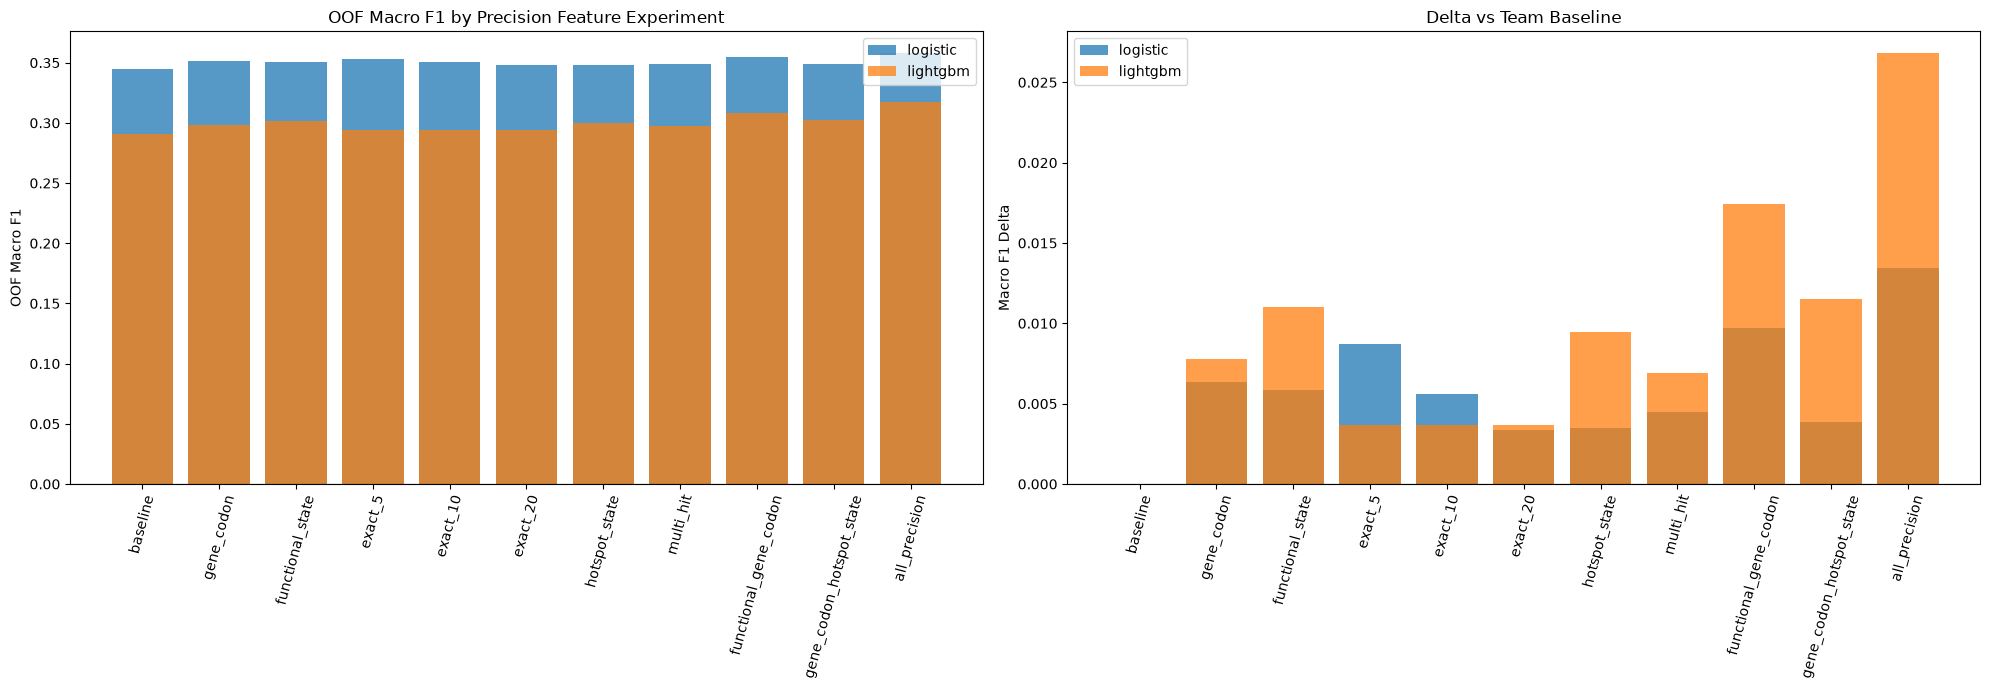

,experiment,model,oof_macro_f1,fold_macro_f1_std,feature_count_mean,delta_vs_baseline
21,baseline_plus_all_precision,lightgbm,0.317413,0.011873,5255.2,0.026832
17,baseline_plus_functional_gene_codon,lightgbm,0.308028,0.012264,4763.0,0.017447
19,baseline_plus_gene_codon_hotspot_state,lightgbm,0.302093,0.014738,4704.4,0.011512
5,baseline_plus_functional_state,lightgbm,0.301624,0.012464,4559.8,0.011043
13,baseline_plus_hotspot_state,lightgbm,0.300035,0.010606,4501.2,0.009454
3,baseline_plus_gene_codon,lightgbm,0.298337,0.011323,4587.2,0.007756
15,baseline_plus_multi_hit,lightgbm,0.297472,0.009871,4442.6,0.006891
7,baseline_plus_exact_5,lightgbm,0.294245,0.007260,4700.4,0.003664
9,baseline_plus_exact_10,lightgbm,0.294245,0.007260,4465.0,0.003664
11,baseline_plus_exact_20,lightgbm,0.294245,0.007260,4406.8,0.003664


In [7]:
plot_data = results.copy()
plot_data['short_experiment'] = plot_data['experiment'].str.replace('baseline_plus_', '', regex=False)
plot_data.loc[plot_data['experiment'] == 'team_baseline_binary', 'short_experiment'] = 'baseline'

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
for model_name, group in plot_data.groupby('model', sort=False):
    axes[0].bar(group['short_experiment'], group['oof_macro_f1'], alpha=0.75, label=model_name)
    axes[1].bar(group['short_experiment'], group['delta_vs_baseline'], alpha=0.75, label=model_name)
axes[0].set_title('OOF Macro F1 by Precision Feature Experiment')
axes[0].set_ylabel('OOF Macro F1')
axes[1].set_title('Delta vs Team Baseline')
axes[1].set_ylabel('Macro F1 Delta')
for ax in axes:
    ax.axhline(0, color='black', linewidth=0.8)
    ax.tick_params(axis='x', rotation=75)
    ax.legend()
plt.tight_layout()
plt.show()

display(results.sort_values(['model', 'delta_vs_baseline'], ascending=[True, False])[['experiment', 'model', 'oof_macro_f1', 'fold_macro_f1_std', 'feature_count_mean', 'delta_vs_baseline']])

## 해석 기준

- `delta_vs_baseline > 0`: 같은 모델과 같은 CV 조건에서 baseline보다 개선된 후보
- `delta_vs_baseline`가 0에 가깝고 feature 수가 감소: 성능 방어형 경량화 후보
- 단일 실험에서 상승했더라도 `fold_macro_f1_std`가 크면 confirmation seed 3회로 재검증
- Logistic과 LightGBM이 함께 상승하면 선형/비선형 모델에 공통적인 정보일 가능성이 높음
- 한 모델에서만 상승하면 모델 구조에 의존하는 feature일 수 있으므로 LB 제출 전 보수적으로 판단

최종 제출용 feature를 선택할 때는 단일 OOF 점수보다 `Macro F1`, fold 표준편차, feature 수, 그리고 기존 LB baseline `0.25157` 방어 여부를 함께 확인합니다.